# Computation: Differential Equations

This notebook demonstrates computational methods for solving and analyzing ODEs:

1. Solving ODEs with `scipy.integrate.solve_ivp`
2. Euler method vs RK4 comparison
3. Phase portrait plotting
4. Lotka-Volterra predator-prey system
5. Stability visualization via linearization

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

rng = np.random.default_rng(seed=42)

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.3
})

## 1. Solving ODEs with `solve_ivp`

### 1.1 Exponential Growth/Decay

The simplest ODE: $y' = ky$, $y(0) = y_0$.

Exact solution: $y(t) = y_0 e^{kt}$.

We solve numerically with `solve_ivp` and compare to the exact solution.

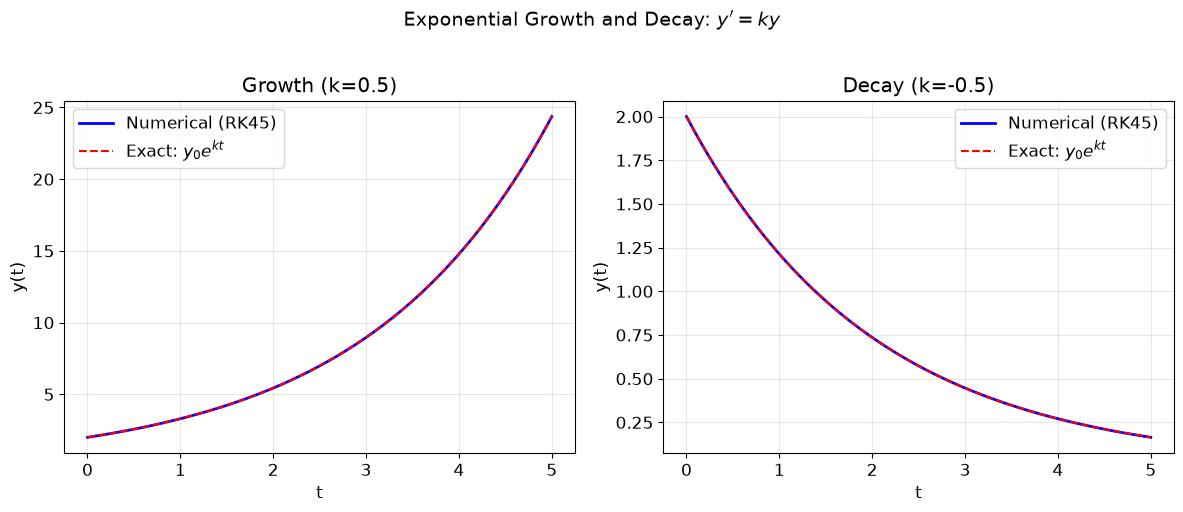

Maximum absolute error (RK45): 1.63e-09


In [2]:
# --- Exponential growth/decay ---
def exponential_ode(t, y, k):
    """dy/dt = k*y"""
    return k * y

y0 = [2.0]
t_span = (0, 5)
t_eval = np.linspace(*t_span, 200)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, k, title in zip(axes, [0.5, -0.5], ['Growth (k=0.5)', 'Decay (k=-0.5)']):
    # Numerical solution
    sol = solve_ivp(exponential_ode, t_span, y0, args=(k,), t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-12)
    
    # Exact solution
    y_exact = y0[0] * np.exp(k * t_eval)
    
    ax.plot(sol.t, sol.y[0], 'b-', linewidth=2, label='Numerical (RK45)')
    ax.plot(t_eval, y_exact, 'r--', linewidth=1.5, label='Exact: $y_0 e^{kt}$')
    ax.set_xlabel('t')
    ax.set_ylabel('y(t)')
    ax.set_title(title)
    ax.legend()

fig.suptitle('Exponential Growth and Decay: $y\' = ky$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Verify accuracy
sol = solve_ivp(exponential_ode, t_span, y0, args=(0.5,), t_eval=t_eval,
                method='RK45', rtol=1e-10, atol=1e-12)
max_error = np.max(np.abs(sol.y[0] - y0[0] * np.exp(0.5 * t_eval)))
print(f'Maximum absolute error (RK45): {max_error:.2e}')

### 1.2 Logistic Equation

The logistic equation $y' = ry(1 - y/K)$ is the prototypical nonlinear ODE in modeling.

Exact solution:
$$y(t) = \frac{K}{1 + \left(\frac{K - y_0}{y_0}\right) e^{-rt}}$$

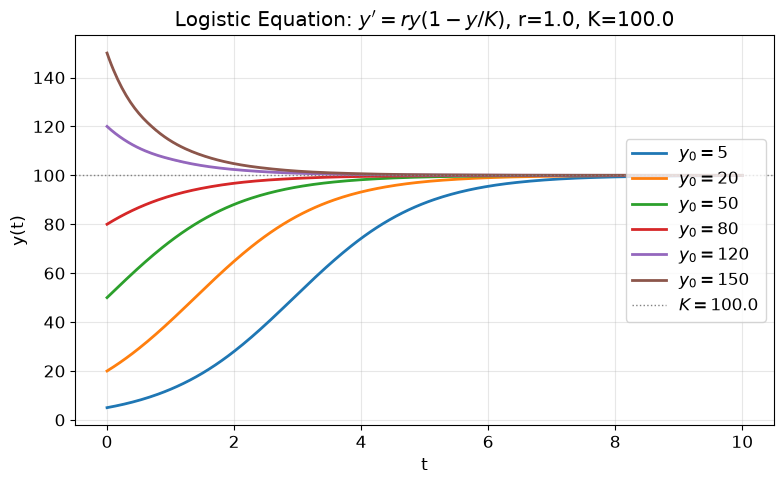

In [3]:
# --- Logistic equation ---
def logistic_ode(t, y, r, K):
    """dy/dt = r*y*(1 - y/K)"""
    return r * y * (1 - y / K)

r, K = 1.0, 100.0
t_span = (0, 10)
t_eval = np.linspace(*t_span, 300)

fig, ax = plt.subplots(figsize=(8, 5))

# Multiple initial conditions
for y0_val in [5, 20, 50, 80, 120, 150]:
    sol = solve_ivp(logistic_ode, t_span, [y0_val], args=(r, K), t_eval=t_eval)
    
    # Exact solution
    y_exact = K / (1 + ((K - y0_val) / y0_val) * np.exp(-r * t_eval))
    
    color = ax.plot(sol.t, sol.y[0], linewidth=2, label=f'$y_0 = {y0_val}$')[0].get_color()
    ax.plot(t_eval, y_exact, '--', color=color, alpha=0.5, linewidth=1)

ax.axhline(y=K, color='gray', linestyle=':', linewidth=1, label=f'$K = {K}$')
ax.set_xlabel('t')
ax.set_ylabel('y(t)')
ax.set_title(f'Logistic Equation: $y\' = ry(1 - y/K)$, r={r}, K={K}')
ax.legend(loc='right')
plt.tight_layout()
plt.show()

**Observation:** All solutions converge to the carrying capacity $K$, regardless of
initial condition (as long as $y_0 > 0$). This is a manifestation of the asymptotic
stability of the equilibrium $y^* = K$.

## 2. Euler Method vs RK4 Comparison

We compare three methods on the ODE $y' = -2ty$, $y(0) = 1$.

Exact solution: $y(t) = e^{-t^2}$ (Gaussian).

This lets us measure the error of each method precisely.

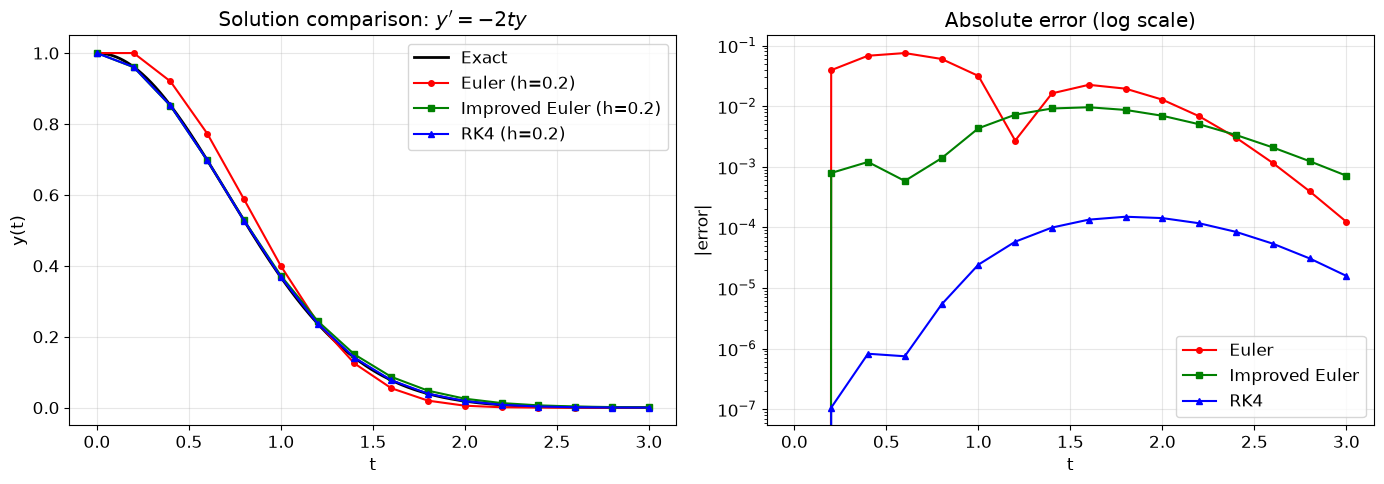

Error at t=3:
  Euler:          1.233843e-04
  Improved Euler: 7.106009e-04
  RK4:            1.578997e-05


In [4]:
def f_gaussian(t, y):
    """dy/dt = -2ty, exact solution: y = exp(-t^2)"""
    return -2 * t * y

def euler_method(f, t_span, y0, h):
    """Forward Euler method."""
    t_start, t_end = t_span
    t_values = [t_start]
    y_values = [y0]
    t, y = t_start, y0
    while t < t_end - 1e-12:
        y = y + h * f(t, y)
        t = t + h
        t_values.append(t)
        y_values.append(y)
    return np.array(t_values), np.array(y_values)

def improved_euler(f, t_span, y0, h):
    """Heun's method (improved Euler)."""
    t_start, t_end = t_span
    t_values = [t_start]
    y_values = [y0]
    t, y = t_start, y0
    while t < t_end - 1e-12:
        k1 = f(t, y)
        y_tilde = y + h * k1
        k2 = f(t + h, y_tilde)
        y = y + h / 2 * (k1 + k2)
        t = t + h
        t_values.append(t)
        y_values.append(y)
    return np.array(t_values), np.array(y_values)

def rk4_method(f, t_span, y0, h):
    """Classical 4th-order Runge-Kutta."""
    t_start, t_end = t_span
    t_values = [t_start]
    y_values = [y0]
    t, y = t_start, y0
    while t < t_end - 1e-12:
        k1 = f(t, y)
        k2 = f(t + h/2, y + h/2 * k1)
        k3 = f(t + h/2, y + h/2 * k2)
        k4 = f(t + h, y + h * k3)
        y = y + h / 6 * (k1 + 2*k2 + 2*k3 + k4)
        t = t + h
        t_values.append(t)
        y_values.append(y)
    return np.array(t_values), np.array(y_values)

# Exact solution
y_exact_fn = lambda t: np.exp(-t**2)
t_span = (0, 3)
y0 = 1.0
h = 0.2

# Solve with each method
t_euler, y_euler = euler_method(f_gaussian, t_span, y0, h)
t_heun, y_heun = improved_euler(f_gaussian, t_span, y0, h)
t_rk4, y_rk4 = rk4_method(f_gaussian, t_span, y0, h)

# Plot solutions
t_fine = np.linspace(*t_span, 500)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: solutions
ax = axes[0]
ax.plot(t_fine, y_exact_fn(t_fine), 'k-', linewidth=2, label='Exact')
ax.plot(t_euler, y_euler, 'ro-', markersize=4, label=f'Euler (h={h})')
ax.plot(t_heun, y_heun, 'gs-', markersize=4, label=f'Improved Euler (h={h})')
ax.plot(t_rk4, y_rk4, 'b^-', markersize=4, label=f'RK4 (h={h})')
ax.set_xlabel('t')
ax.set_ylabel('y(t)')
ax.set_title("Solution comparison: $y' = -2ty$")
ax.legend()

# Right: errors
ax = axes[1]
ax.semilogy(t_euler, np.abs(y_euler - y_exact_fn(t_euler)), 'ro-', markersize=4, label='Euler')
ax.semilogy(t_heun, np.abs(y_heun - y_exact_fn(t_heun)), 'gs-', markersize=4, label='Improved Euler')
ax.semilogy(t_rk4, np.abs(y_rk4 - y_exact_fn(t_rk4)), 'b^-', markersize=4, label='RK4')
ax.set_xlabel('t')
ax.set_ylabel('|error|')
ax.set_title('Absolute error (log scale)')
ax.legend()

plt.tight_layout()
plt.show()

print(f'Error at t=3:')
print(f'  Euler:          {abs(y_euler[-1] - y_exact_fn(3)):.6e}')
print(f'  Improved Euler: {abs(y_heun[-1] - y_exact_fn(3)):.6e}')
print(f'  RK4:            {abs(y_rk4[-1] - y_exact_fn(3)):.6e}')

### Convergence Order Verification

Theory predicts:
- Euler: global error $\sim O(h)$
- Improved Euler: global error $\sim O(h^2)$
- RK4: global error $\sim O(h^4)$

We verify by measuring the error at $t=3$ for decreasing step sizes.

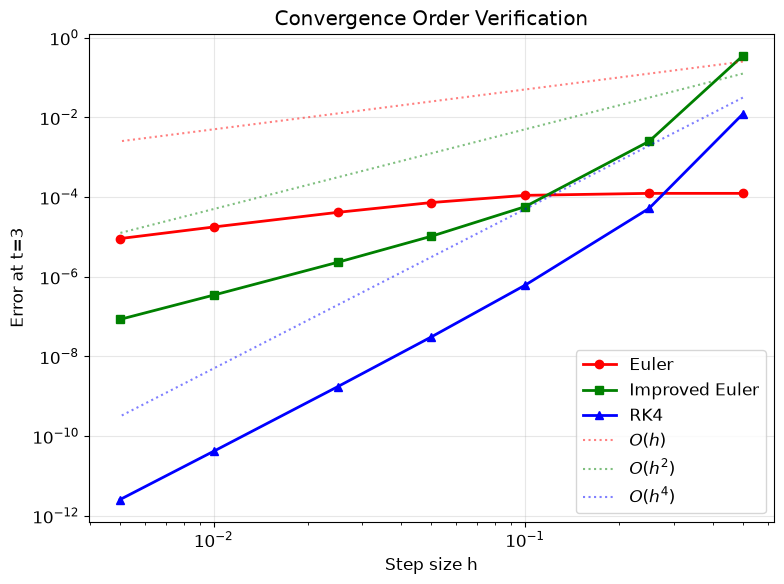

Euler          : estimated order = 0.90
Improved Euler : estimated order = 2.09
RK4            : estimated order = 4.08


In [5]:
# --- Convergence order verification ---
h_values = np.array([0.5, 0.25, 0.1, 0.05, 0.025, 0.01, 0.005])
errors_euler = []
errors_heun = []
errors_rk4 = []

for h in h_values:
    _, y_e = euler_method(f_gaussian, t_span, y0, h)
    _, y_h = improved_euler(f_gaussian, t_span, y0, h)
    _, y_r = rk4_method(f_gaussian, t_span, y0, h)
    errors_euler.append(abs(y_e[-1] - y_exact_fn(3)))
    errors_heun.append(abs(y_h[-1] - y_exact_fn(3)))
    errors_rk4.append(abs(y_r[-1] - y_exact_fn(3)))

errors_euler = np.array(errors_euler)
errors_heun = np.array(errors_heun)
errors_rk4 = np.array(errors_rk4)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(h_values, errors_euler, 'ro-', linewidth=2, markersize=6, label='Euler')
ax.loglog(h_values, errors_heun, 'gs-', linewidth=2, markersize=6, label='Improved Euler')
ax.loglog(h_values, errors_rk4, 'b^-', linewidth=2, markersize=6, label='RK4')

# Reference slopes
ax.loglog(h_values, 0.5 * h_values**1, 'r:', alpha=0.5, label='$O(h)$')
ax.loglog(h_values, 0.5 * h_values**2, 'g:', alpha=0.5, label='$O(h^2)$')
ax.loglog(h_values, 0.5 * h_values**4, 'b:', alpha=0.5, label='$O(h^4)$')

ax.set_xlabel('Step size h')
ax.set_ylabel('Error at t=3')
ax.set_title('Convergence Order Verification')
ax.legend()
plt.tight_layout()
plt.show()

# Estimate convergence orders
for name, errors in [('Euler', errors_euler), ('Improved Euler', errors_heun), ('RK4', errors_rk4)]:
    orders = np.log(errors[:-1] / errors[1:]) / np.log(h_values[:-1] / h_values[1:])
    print(f'{name:15s}: estimated order = {np.mean(orders[-3:]):.2f}')

## 3. Phase Portrait Plotting

### 3.1 Linear Systems

For $\mathbf{x}' = A\mathbf{x}$, the phase portrait is determined by the eigenvalues of $A$.

We demonstrate the four main types: stable node, unstable node, saddle, and spiral.

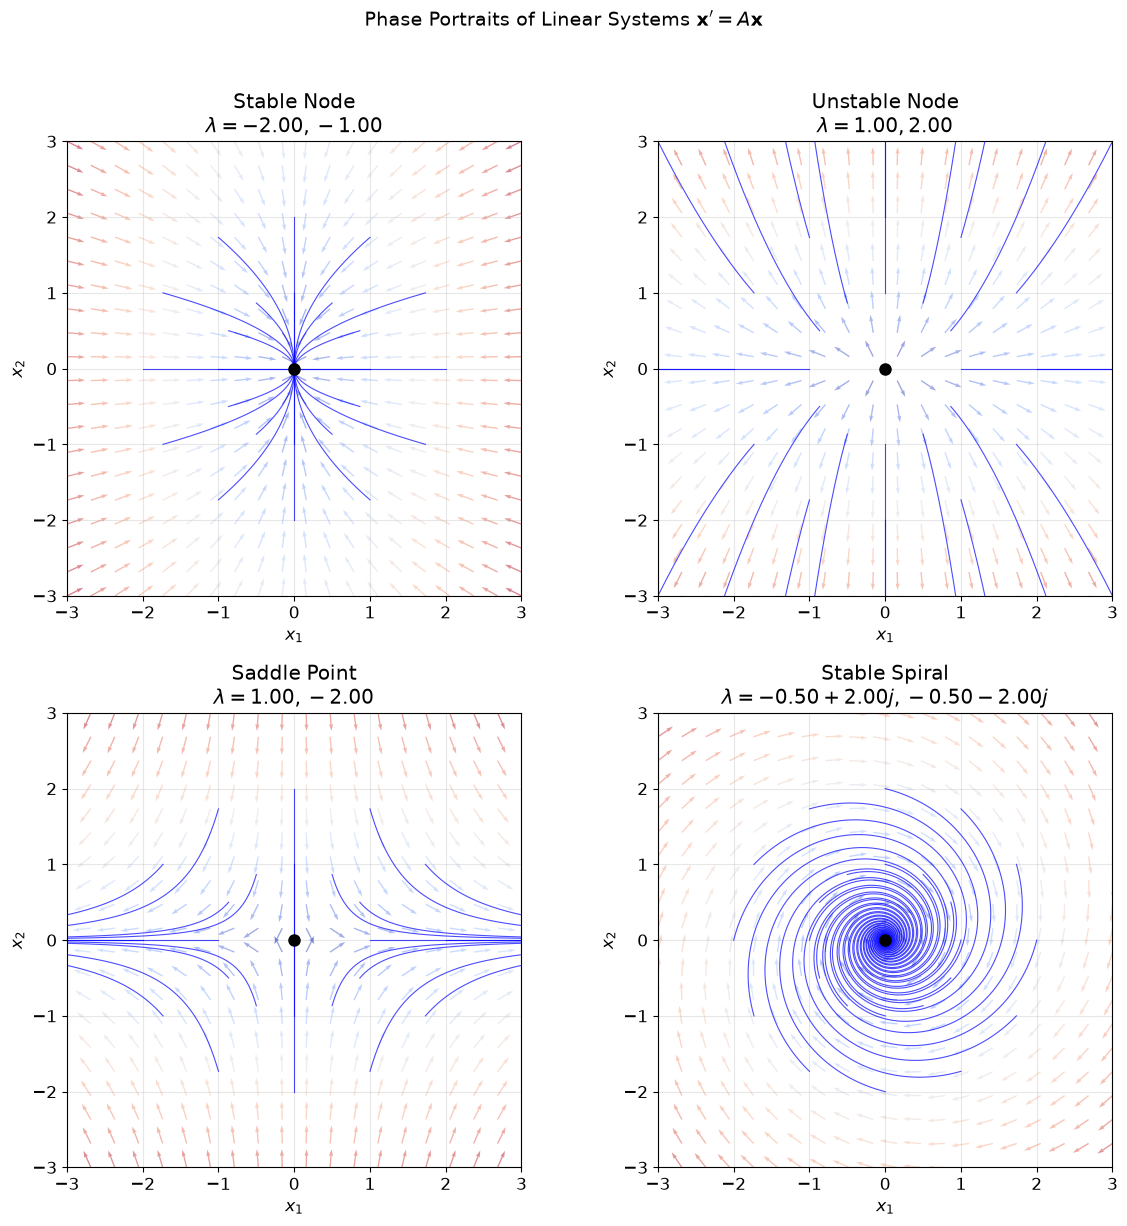

In [6]:
def plot_phase_portrait(A, title, ax, t_max=5):
    """Plot phase portrait for x' = Ax."""
    # Vector field
    x_range = np.linspace(-3, 3, 20)
    y_range = np.linspace(-3, 3, 20)
    X, Y = np.meshgrid(x_range, y_range)
    U = A[0, 0] * X + A[0, 1] * Y
    V = A[1, 0] * X + A[1, 1] * Y
    speed = np.sqrt(U**2 + V**2)
    speed[speed == 0] = 1
    ax.quiver(X, Y, U/speed, V/speed, speed, cmap='coolwarm', alpha=0.5, scale=25)
    
    # Trajectories from various initial conditions
    def system(t, state):
        return A @ state
    
    angles = np.linspace(0, 2*np.pi, 12, endpoint=False)
    radii = [1.0, 2.0]
    for r in radii:
        for angle in angles:
            x0 = [r * np.cos(angle), r * np.sin(angle)]
            sol = solve_ivp(system, (0, t_max), x0, t_eval=np.linspace(0, t_max, 500),
                           max_step=0.05)
            # Only plot if trajectory stays in view
            mask = (np.abs(sol.y[0]) < 5) & (np.abs(sol.y[1]) < 5)
            ax.plot(sol.y[0][mask], sol.y[1][mask], 'b-', linewidth=0.8, alpha=0.7)
    
    # Mark origin
    eigvals = np.linalg.eigvals(A)
    ax.plot(0, 0, 'ko', markersize=8)
    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_title(f'{title}\n$\\lambda = {eigvals[0]:.2f}, {eigvals[1]:.2f}$')
    ax.set_aspect('equal')

# Four cases
fig, axes = plt.subplots(2, 2, figsize=(12, 12))

# Stable node: both eigenvalues negative real
A1 = np.array([[-2, 0], [0, -1]])
plot_phase_portrait(A1, 'Stable Node', axes[0, 0])

# Unstable node: both eigenvalues positive real
A2 = np.array([[1, 0], [0, 2]])
plot_phase_portrait(A2, 'Unstable Node', axes[0, 1], t_max=1.5)

# Saddle: eigenvalues of opposite sign
A3 = np.array([[1, 0], [0, -2]])
plot_phase_portrait(A3, 'Saddle Point', axes[1, 0], t_max=2)

# Stable spiral: complex eigenvalues with negative real part
A4 = np.array([[-0.5, 2], [-2, -0.5]])
plot_phase_portrait(A4, 'Stable Spiral', axes[1, 1], t_max=8)

fig.suptitle('Phase Portraits of Linear Systems $\\mathbf{x}\' = A\\mathbf{x}$',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 4. Lotka-Volterra Predator-Prey System

The Lotka-Volterra equations model the interaction between predator and prey populations:

$$\frac{dx}{dt} = \alpha x - \beta x y \quad \text{(prey)}$$
$$\frac{dy}{dt} = \delta x y - \gamma y \quad \text{(predator)}$$

where:
- $x(t)$: prey population
- $y(t)$: predator population
- $\alpha$: prey growth rate
- $\beta$: predation rate
- $\delta$: predator growth efficiency
- $\gamma$: predator death rate

Coexistence equilibrium: x* = 20.0, y* = 10.0


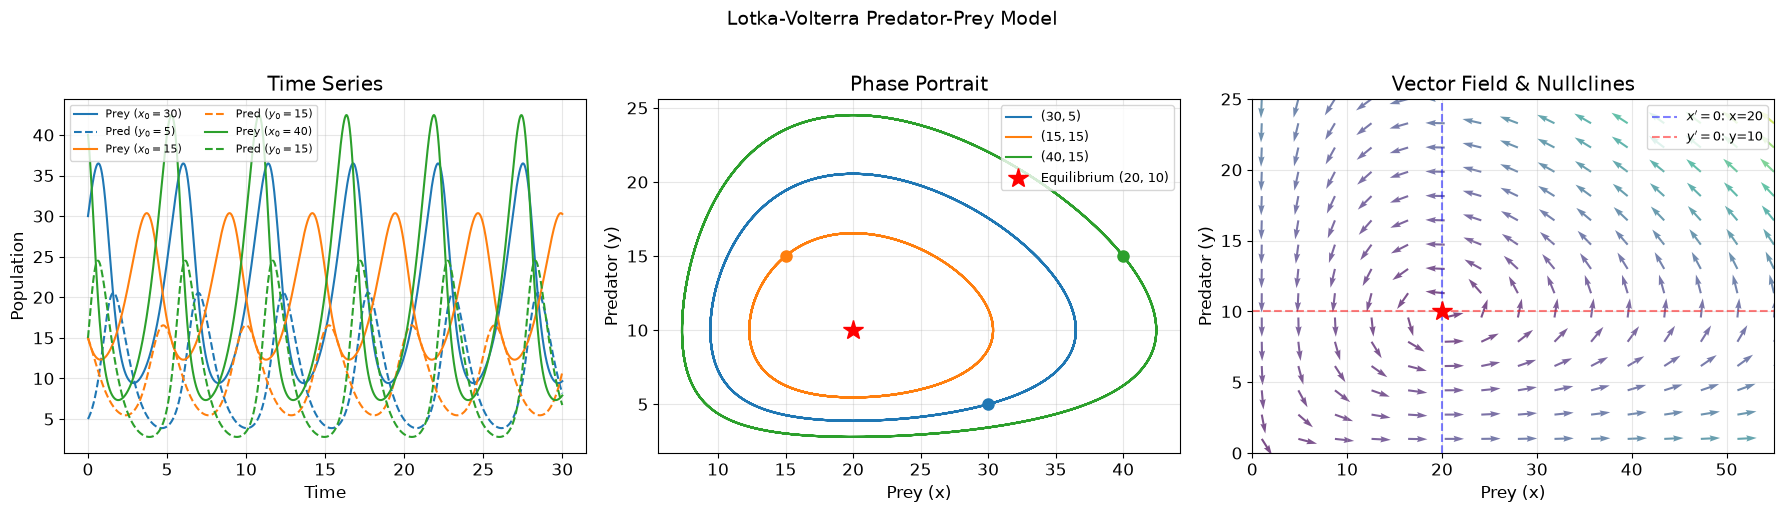

In [7]:
# --- Lotka-Volterra system ---
def lotka_volterra(t, state, alpha, beta, delta, gamma):
    """Lotka-Volterra predator-prey system."""
    x, y = state
    dxdt = alpha * x - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

# Parameters
alpha = 1.0   # prey growth rate
beta = 0.1    # predation rate
delta = 0.075 # predator efficiency
gamma = 1.5   # predator death rate
params = (alpha, beta, delta, gamma)

# Coexistence equilibrium
x_eq = gamma / delta
y_eq = alpha / beta
print(f'Coexistence equilibrium: x* = {x_eq:.1f}, y* = {y_eq:.1f}')

# Solve from multiple initial conditions
t_span = (0, 30)
t_eval = np.linspace(*t_span, 2000)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

initial_conditions = [
    [30, 5],
    [15, 15],
    [40, 15],
]
colors = ['tab:blue', 'tab:orange', 'tab:green']

for ic, color in zip(initial_conditions, colors):
    sol = solve_ivp(lotka_volterra, t_span, ic, args=params, t_eval=t_eval,
                    method='RK45', rtol=1e-10, atol=1e-12)
    
    # Time series
    axes[0].plot(sol.t, sol.y[0], '-', color=color, linewidth=1.5,
                label=f'Prey ($x_0={ic[0]}$)')
    axes[0].plot(sol.t, sol.y[1], '--', color=color, linewidth=1.5,
                label=f'Pred ($y_0={ic[1]}$)')
    
    # Phase portrait
    axes[1].plot(sol.y[0], sol.y[1], '-', color=color, linewidth=1.5,
                label=f'$({ic[0]}, {ic[1]})$')
    axes[1].plot(ic[0], ic[1], 'o', color=color, markersize=8)

# Time series plot
axes[0].set_xlabel('Time')
axes[0].set_ylabel('Population')
axes[0].set_title('Time Series')
axes[0].legend(fontsize=8, ncol=2)

# Phase portrait
axes[1].plot(x_eq, y_eq, 'r*', markersize=15, zorder=5, label=f'Equilibrium ({x_eq:.0f}, {y_eq:.0f})')
axes[1].set_xlabel('Prey (x)')
axes[1].set_ylabel('Predator (y)')
axes[1].set_title('Phase Portrait')
axes[1].legend(fontsize=9)

# Vector field
x_range = np.linspace(1, 55, 15)
y_range = np.linspace(1, 25, 15)
X, Y = np.meshgrid(x_range, y_range)
U = alpha * X - beta * X * Y
V = delta * X * Y - gamma * Y
speed = np.sqrt(U**2 + V**2)
speed[speed == 0] = 1
axes[2].quiver(X, Y, U/speed, V/speed, speed, cmap='viridis', alpha=0.7)
axes[2].plot(x_eq, y_eq, 'r*', markersize=15, zorder=5)

# Add nullclines
x_vals = np.linspace(0.5, 55, 200)
axes[2].axvline(x=x_eq, color='blue', linestyle='--', alpha=0.5, label=f'$x\' = 0$: x={x_eq:.0f}')
axes[2].axhline(y=y_eq, color='red', linestyle='--', alpha=0.5, label=f'$y\' = 0$: y={y_eq:.0f}')
axes[2].set_xlabel('Prey (x)')
axes[2].set_ylabel('Predator (y)')
axes[2].set_title('Vector Field & Nullclines')
axes[2].legend(fontsize=9)
axes[2].set_xlim(0, 55)
axes[2].set_ylim(0, 25)

fig.suptitle('Lotka-Volterra Predator-Prey Model', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Key observations:**
- The populations oscillate periodically (the Lotka-Volterra system is a Hamiltonian system).
- Orbits are **closed curves** in the phase plane — the system is a **center**.
- Predator peaks **lag** behind prey peaks (more prey → more predators → fewer prey → fewer predators → cycle repeats).
- The nullclines $x' = 0$ and $y' = 0$ divide the phase plane into four regions with different flow directions.

## 5. Stability Visualization

### 5.1 Linearization of Lotka-Volterra

At the coexistence equilibrium $(x^*, y^*) = (\gamma/\delta, \alpha/\beta)$,
the Jacobian is:

$$J = \begin{pmatrix} 0 & -\beta x^* \\ \delta y^* & 0 \end{pmatrix}$$

The eigenvalues are $\lambda = \pm i\sqrt{\alpha\gamma}$ — pure imaginary,
confirming the equilibrium is a **center** (neutrally stable, not asymptotically stable).

In [8]:
# --- Linearization analysis ---
J_lv = np.array([
    [0, -beta * x_eq],
    [delta * y_eq, 0]
])

eigvals_lv = np.linalg.eigvals(J_lv)
print('Lotka-Volterra Jacobian at coexistence equilibrium:')
print(f'  J = \n{J_lv}')
print(f'  Eigenvalues: {eigvals_lv}')
print(f'  Real parts: {eigvals_lv.real}')
print(f'  -> Center (pure imaginary eigenvalues)')
print(f'  Frequency of oscillation: omega = {np.abs(eigvals_lv[0].imag):.4f}')
print(f'  Expected: sqrt(alpha*gamma) = {np.sqrt(alpha*gamma):.4f}')

Lotka-Volterra Jacobian at coexistence equilibrium:
  J = 
[[ 0.   -2.  ]
 [ 0.75  0.  ]]
  Eigenvalues: [0.+1.22474487j 0.-1.22474487j]
  Real parts: [0. 0.]
  -> Center (pure imaginary eigenvalues)
  Frequency of oscillation: omega = 1.2247
  Expected: sqrt(alpha*gamma) = 1.2247


### 5.2 Modified System with Damping

Adding a self-limitation term to the prey makes the coexistence equilibrium
asymptotically stable:

$$x' = \alpha x(1 - x/K) - \beta xy$$
$$y' = \delta xy - \gamma y$$

This is more realistic — prey cannot grow without bound even without predators.

Modified equilibrium: x* = 20.0, y* = 8.00
Eigenvalues: [-0.1+1.09087121j -0.1-1.09087121j]
Real parts: [-0.1 -0.1] -> stable


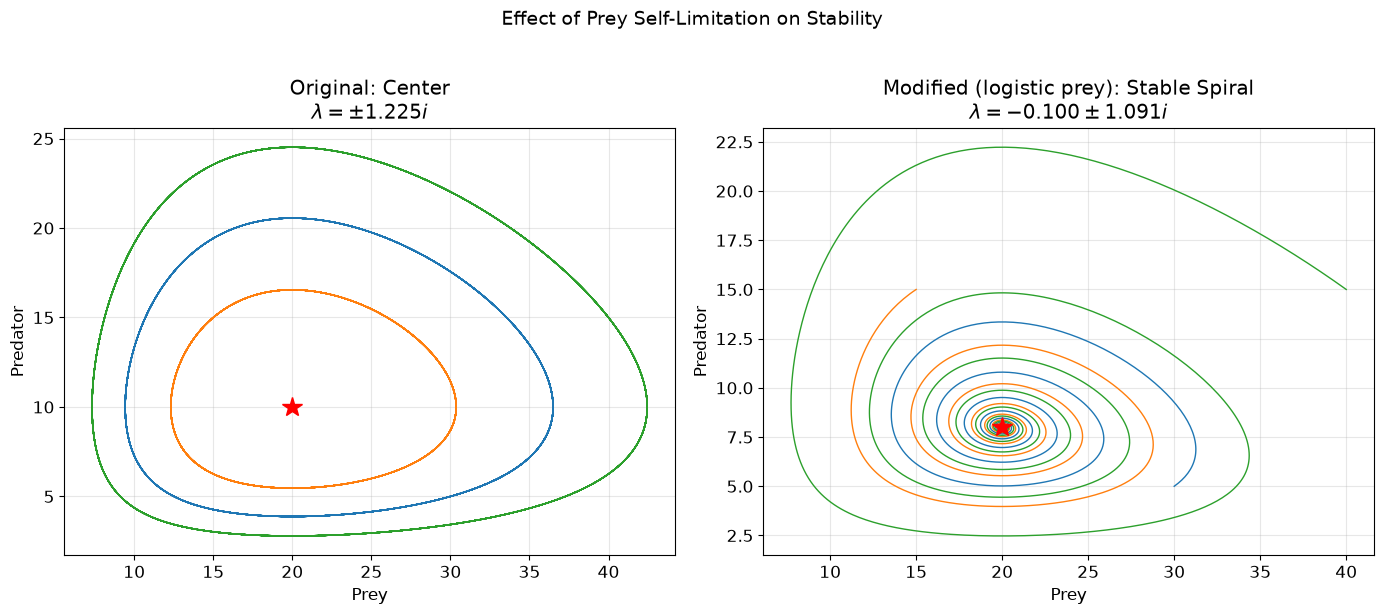

In [9]:
# --- Modified system with logistic prey growth ---
def lotka_volterra_logistic(t, state, alpha, beta, delta, gamma, K):
    x, y = state
    dxdt = alpha * x * (1 - x/K) - beta * x * y
    dydt = delta * x * y - gamma * y
    return [dxdt, dydt]

K_prey = 100.0
params_log = (alpha, beta, delta, gamma, K_prey)

# New coexistence equilibrium
x_eq_log = gamma / delta
y_eq_log = (alpha / beta) * (1 - x_eq_log / K_prey)
print(f'Modified equilibrium: x* = {x_eq_log:.1f}, y* = {y_eq_log:.2f}')

# Jacobian at new equilibrium
J_log = np.array([
    [alpha * (1 - 2*x_eq_log/K_prey) - beta*y_eq_log, -beta*x_eq_log],
    [delta*y_eq_log, delta*x_eq_log - gamma]
])
eigvals_log = np.linalg.eigvals(J_log)
print(f'Eigenvalues: {eigvals_log}')
print(f'Real parts: {eigvals_log.real} -> {"stable" if np.all(eigvals_log.real < 0) else "unstable"}')

# Compare original and modified
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

t_span_long = (0, 60)
t_eval_long = np.linspace(*t_span_long, 3000)

for ic in [[30, 5], [15, 15], [40, 15]]:
    # Original
    sol1 = solve_ivp(lotka_volterra, t_span_long, ic, args=params,
                     t_eval=t_eval_long, rtol=1e-10, atol=1e-12)
    axes[0].plot(sol1.y[0], sol1.y[1], linewidth=1)
    
    # Modified
    sol2 = solve_ivp(lotka_volterra_logistic, t_span_long, ic, args=params_log,
                     t_eval=t_eval_long, rtol=1e-10, atol=1e-12)
    axes[1].plot(sol2.y[0], sol2.y[1], linewidth=1)

axes[0].plot(x_eq, y_eq, 'r*', markersize=15, zorder=5)
axes[0].set_title(f'Original: Center\n$\\lambda = \\pm {np.abs(eigvals_lv[0].imag):.3f}i$')
axes[0].set_xlabel('Prey')
axes[0].set_ylabel('Predator')

axes[1].plot(x_eq_log, y_eq_log, 'r*', markersize=15, zorder=5)
axes[1].set_title(f'Modified (logistic prey): Stable Spiral\n$\\lambda = {eigvals_log[0].real:.3f} \\pm {np.abs(eigvals_log[0].imag):.3f}i$')
axes[1].set_xlabel('Prey')
axes[1].set_ylabel('Predator')

fig.suptitle('Effect of Prey Self-Limitation on Stability', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 5.3 Eigenvalue Map for Stability

The stability of an equilibrium is determined by where its eigenvalues fall
in the complex plane:

- **Left half-plane** ($\operatorname{Re}(\lambda) < 0$): asymptotically stable
- **Imaginary axis** ($\operatorname{Re}(\lambda) = 0$): marginally stable / center
- **Right half-plane** ($\operatorname{Re}(\lambda) > 0$): unstable

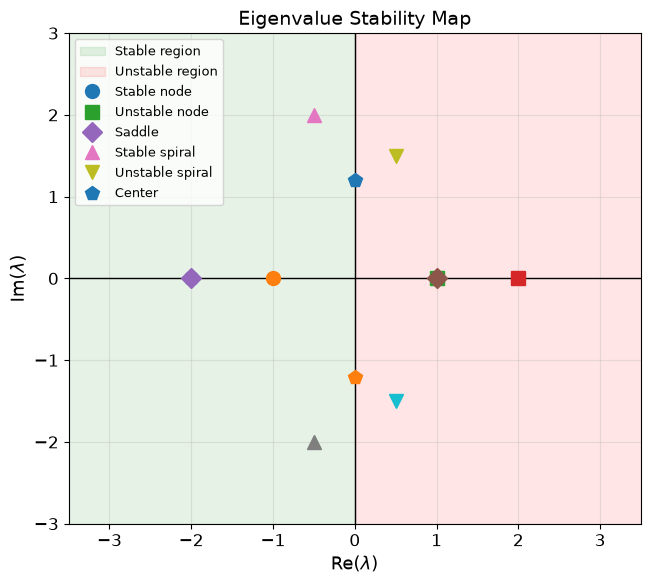

In [10]:
# --- Eigenvalue stability map ---
fig, ax = plt.subplots(figsize=(8, 6))

# Shade regions
ax.axvspan(-4, 0, alpha=0.1, color='green', label='Stable region')
ax.axvspan(0, 4, alpha=0.1, color='red', label='Unstable region')
ax.axvline(x=0, color='black', linewidth=1)
ax.axhline(y=0, color='black', linewidth=1)

# Example eigenvalues from different systems
systems = {
    'Stable node': [(-2, 0), (-1, 0)],
    'Unstable node': [(1, 0), (2, 0)],
    'Saddle': [(-2, 0), (1, 0)],
    'Stable spiral': [(-0.5, 2), (-0.5, -2)],
    'Unstable spiral': [(0.5, 1.5), (0.5, -1.5)],
    'Center': [(0, 1.2), (0, -1.2)],
}

markers = ['o', 's', 'D', '^', 'v', 'p']
for (name, eigs), marker in zip(systems.items(), markers):
    for i, (re, im) in enumerate(eigs):
        label = name if i == 0 else None
        ax.plot(re, im, marker, markersize=10, label=label)

ax.set_xlabel('Re($\\lambda$)', fontsize=13)
ax.set_ylabel('Im($\\lambda$)', fontsize=13)
ax.set_title('Eigenvalue Stability Map', fontsize=14)
ax.legend(loc='upper left', fontsize=9)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

This notebook demonstrated:

1. **`solve_ivp`** for solving ODEs numerically (exponential, logistic)
2. **Euler vs RK4**: RK4 achieves dramatically better accuracy ($O(h^4)$ vs $O(h)$)
3. **Phase portraits**: Visual classification of linear systems by eigenvalue structure
4. **Lotka-Volterra**: Closed orbits (center), nullclines, and periodic oscillations
5. **Stability**: Linearization, Jacobian eigenvalues, and the effect of model modifications

**Key takeaway:** The eigenvalues of the Jacobian at an equilibrium determine the
qualitative behavior of a dynamical system near that equilibrium. This connects
linear algebra directly to modeling predictions.